# Credit Risk Scoring System - Complete ML Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import joblib

df = pd.read_csv('../data/raw/german_credit_data.csv', index_col=0)
print(df.shape)
df.head()

(1000, 10)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


## 1. Data Preprocessing

In [2]:
print('Shape:', df.shape)
print('\nMissing values:\n', df.isnull().sum())
print('\nData types:\n', df.dtypes)
print('\nClass distribution:\n', df['Risk'].value_counts())

Shape: (1000, 10)

Missing values:
 Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Data types:
 Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

Class distribution:
 Risk
good    700
bad     300
Name: count, dtype: int64


In [3]:
# Fill missing categoricals with mode
for col in ['Saving accounts', 'Checking account']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Encode target: good=0, bad=1
df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})

print('Missing after fill:\n', df.isnull().sum())
print('\nClass distribution after encoding:\n', df['Risk'].value_counts())

Missing after fill:
 Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

Class distribution after encoding:
 Risk
0    700
1    300
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)

In [4]:
df.describe()

,Age,Job,Credit amount,Duration,Risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000,0.300000
std,11.375469,0.653614,2822.736876,12.058814,0.458487
min,19.000000,0.000000,250.000000,4.000000,0.000000
25%,27.000000,2.000000,1365.500000,12.000000,0.000000
50%,33.000000,2.000000,2319.500000,18.000000,0.000000
75%,42.000000,2.000000,3972.250000,24.000000,1.000000
max,75.000000,3.000000,18424.000000,72.000000,1.000000


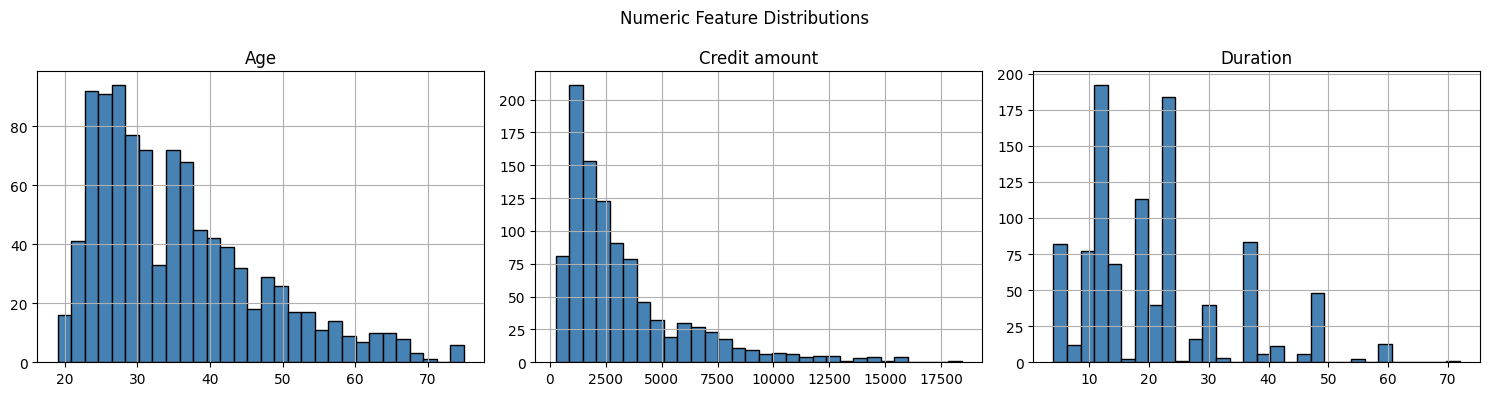

In [5]:
# Numeric distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Credit amount', 'Duration']):
    df[col].hist(ax=ax, bins=30, edgecolor='black', color='steelblue')
    ax.set_title(col)
plt.suptitle('Numeric Feature Distributions')
plt.tight_layout()
plt.show()

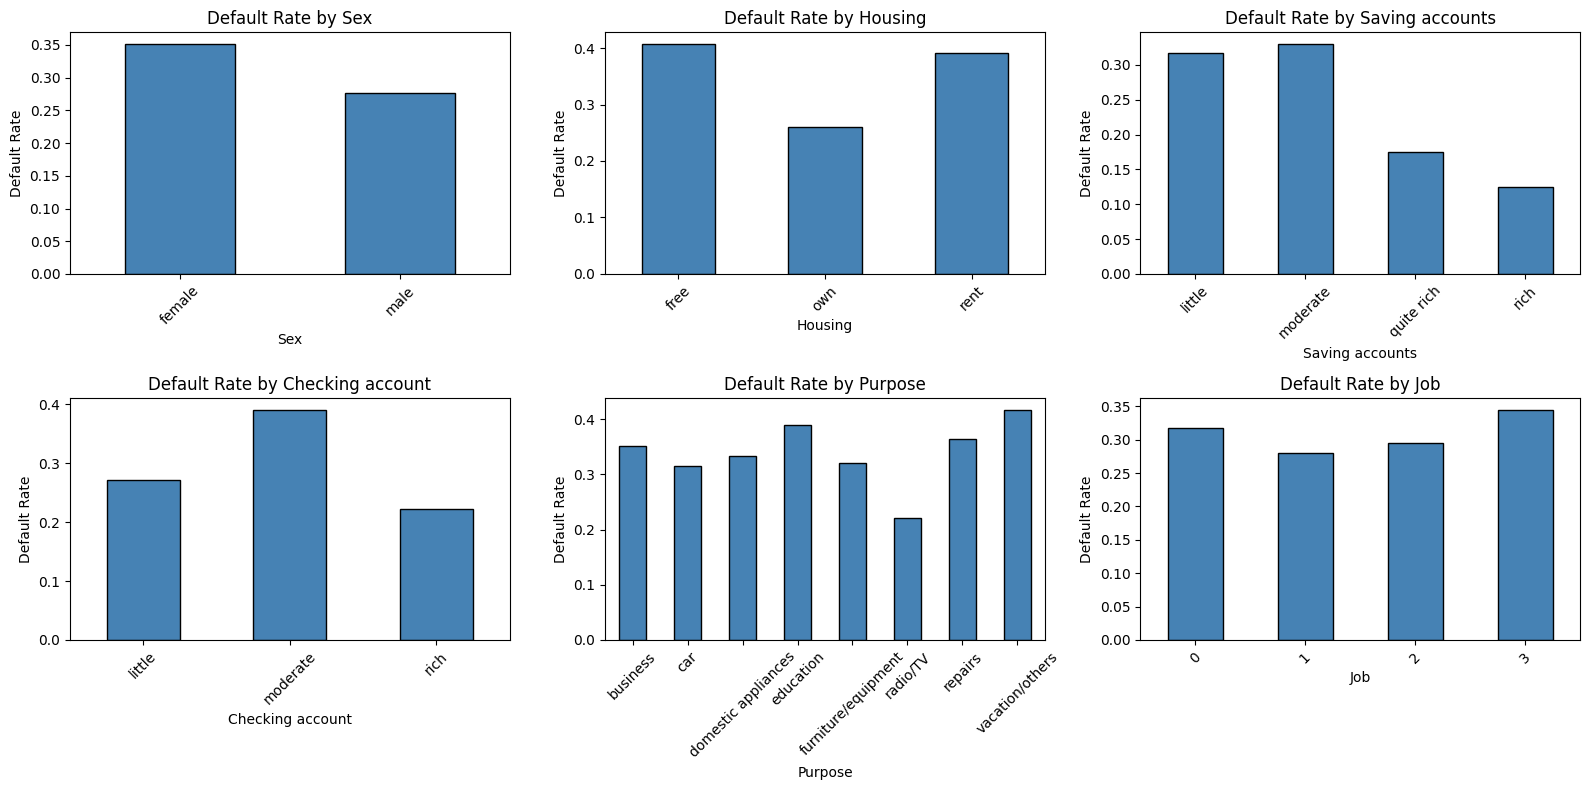

In [6]:
# Default rate by categorical features
cat_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Job']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    df.groupby(col)['Risk'].mean().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Default Rate by {col}')
    ax.set_ylabel('Default Rate')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

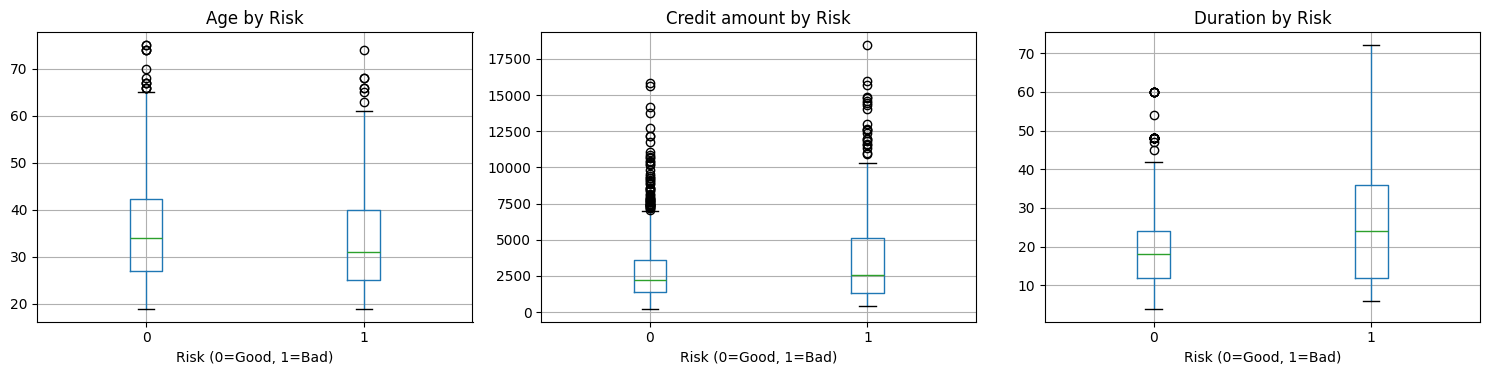

In [7]:
# Box plots: numeric vs Risk
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Credit amount', 'Duration']):
    df.boxplot(column=col, by='Risk', ax=ax)
    ax.set_title(f'{col} by Risk')
    ax.set_xlabel('Risk (0=Good, 1=Bad)')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 3. Correlation Analysis

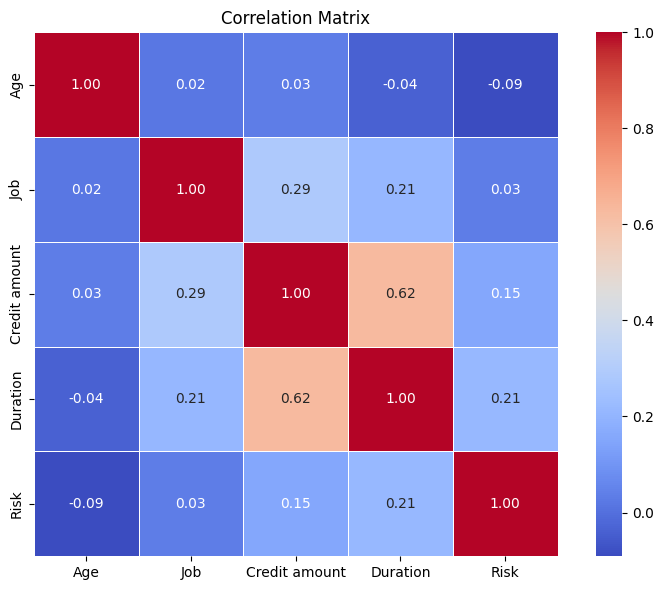


Correlation with Risk (sorted):
 Risk             1.000000
Duration         0.214927
Credit amount    0.154739
Job              0.032735
Age             -0.091127
Name: Risk, dtype: float64


In [8]:
num_cols = ['Age', 'Job', 'Credit amount', 'Duration', 'Risk']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print('\nCorrelation with Risk (sorted):\n', corr['Risk'].sort_values(ascending=False))

## 4. Chi-Square Test (Categorical Features vs Risk)

In [9]:
chi2_results = []
for col in ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']:
    ct = pd.crosstab(df[col], df['Risk'])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi2_results.append({
        'Feature': col,
        'Chi2 Stat': round(chi2, 2),
        'p-value': round(p, 4),
        'DOF': dof,
        'Significant (p<0.05)': p < 0.05
    })

chi2_df = pd.DataFrame(chi2_results)
print(chi2_df.to_string(index=False))

         Feature  Chi2 Stat  p-value  DOF  Significant (p<0.05)
             Sex       5.35   0.0207    1                  True
         Housing      18.20   0.0001    2                  True
 Saving accounts      13.22   0.0042    3                  True
Checking account      14.95   0.0006    2                  True
         Purpose      13.64   0.0579    7                 False


## 5. Hypothesis Testing (Numerical Features vs Risk)

In [10]:
# H0: No difference in distribution between Good and Bad risk groups
# Mann-Whitney U test (non-parametric, no normality assumption)
good = df[df['Risk'] == 0]
bad  = df[df['Risk'] == 1]

hyp_results = []
for col in ['Age', 'Credit amount', 'Duration']:
    stat, p = mannwhitneyu(good[col], bad[col], alternative='two-sided')
    hyp_results.append({
        'Feature': col,
        'Good Mean': round(good[col].mean(), 2),
        'Bad Mean':  round(bad[col].mean(), 2),
        'U-Stat': round(stat, 2),
        'p-value': round(p, 4),
        'Reject H0 (p<0.05)': p < 0.05
    })

hyp_df = pd.DataFrame(hyp_results)
print(hyp_df.to_string(index=False))

      Feature  Good Mean  Bad Mean   U-Stat  p-value  Reject H0 (p<0.05)
          Age      36.22     33.96 119833.0   0.0004                True
Credit amount    2985.46   3938.13  93480.0   0.0059                True
     Duration      19.21     24.86  77995.5   0.0000                True


## 6. Feature Engineering & Train-Test Split

In [11]:
# Feature engineering
df['Credit_per_Duration'] = df['Credit amount'] / df['Duration']
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 50, 100],
                          labels=['Young', 'Adult', 'Middle', 'Senior'])

X = df.drop('Risk', axis=1)
y = df['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')
print(f'\nTrain class dist:\n{y_train.value_counts()}')
print(f'\nTest class dist:\n{y_test.value_counts()}')

Train size : (800, 11)
Test size  : (200, 11)

Train class dist:
Risk
0    560
1    240
Name: count, dtype: int64

Test class dist:
Risk
0    140
1     60
Name: count, dtype: int64


## 7. Pipeline Building

In [ ]:
num_features = ['Age', 'Job', 'Credit amount', 'Duration', 'Credit_per_Duration']
cat_features  = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Age_Group']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':              XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

print('Preprocessor and models defined.')
print('Numeric features :', num_features)
print('Categorical features:', cat_features)

Preprocessor and models defined.
Numeric features : ['Age', 'Job', 'Credit amount', 'Duration', 'Credit_per_Duration']
Categorical features: ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Age_Group']


## 8. Cross-Validation

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name:25s} | AUC = {scores.mean():.4f} +/- {scores.std():.4f} | Folds: {np.round(scores, 4)}')

Logistic Regression       | AUC = 0.6648 +/- 0.0253 | Folds: [0.686  0.6205 0.6752 0.6536 0.6886]
Random Forest             | AUC = 0.6398 +/- 0.0456 | Folds: [0.6406 0.573  0.639  0.6302 0.7163]
XGBoost                   | AUC = 0.6323 +/- 0.0523 | Folds: [0.6436 0.5569 0.6047 0.6401 0.7161]


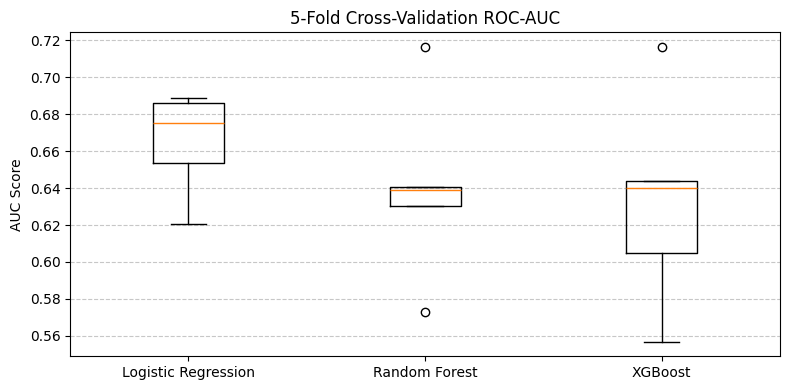

In [14]:
plt.figure(figsize=(8, 4))
plt.boxplot(cv_results.values(), labels=cv_results.keys())
plt.title('5-Fold Cross-Validation ROC-AUC')
plt.ylabel('AUC Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 9. Model Training & Evaluation

In [15]:
eval_results = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    eval_results[name] = {'pipeline': pipe, 'acc': acc, 'auc': auc, 'y_pred': y_pred}

    print(f'\n=== {name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Good (0)', 'Bad (1)']))


=== Logistic Regression ===
Accuracy : 0.7300
ROC-AUC  : 0.6190
              precision    recall  f1-score   support

    Good (0)       0.75      0.93      0.83       140
     Bad (1)       0.62      0.27      0.37        60

    accuracy                           0.73       200
   macro avg       0.68      0.60      0.60       200
weighted avg       0.71      0.73      0.69       200


=== Random Forest ===
Accuracy : 0.7300
ROC-AUC  : 0.6554
              precision    recall  f1-score   support

    Good (0)       0.76      0.90      0.82       140
     Bad (1)       0.59      0.33      0.43        60

    accuracy                           0.73       200
   macro avg       0.67      0.62      0.62       200
weighted avg       0.71      0.73      0.70       200


=== XGBoost ===
Accuracy : 0.6800
ROC-AUC  : 0.6430
              precision    recall  f1-score   support

    Good (0)       0.74      0.83      0.78       140
     Bad (1)       0.45      0.33      0.38        60

    a

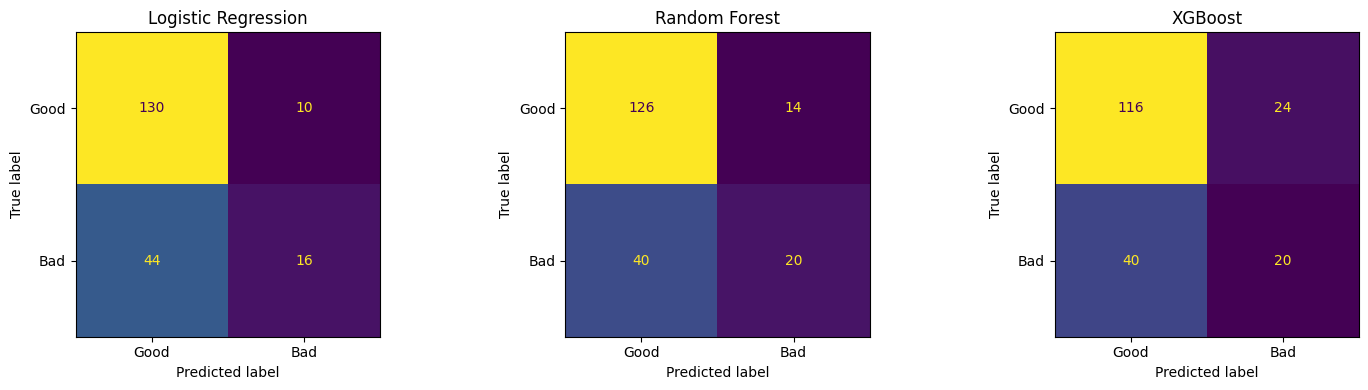

In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, eval_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Good', 'Bad']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [17]:
# Model comparison summary
summary = pd.DataFrame([
    {'Model': name, 'Accuracy': round(res['acc'], 4), 'ROC-AUC': round(res['auc'], 4)}
    for name, res in eval_results.items()
]).sort_values('ROC-AUC', ascending=False)
print(summary.to_string(index=False))

              Model  Accuracy  ROC-AUC
      Random Forest      0.73   0.6554
            XGBoost      0.68   0.6430
Logistic Regression      0.73   0.6190


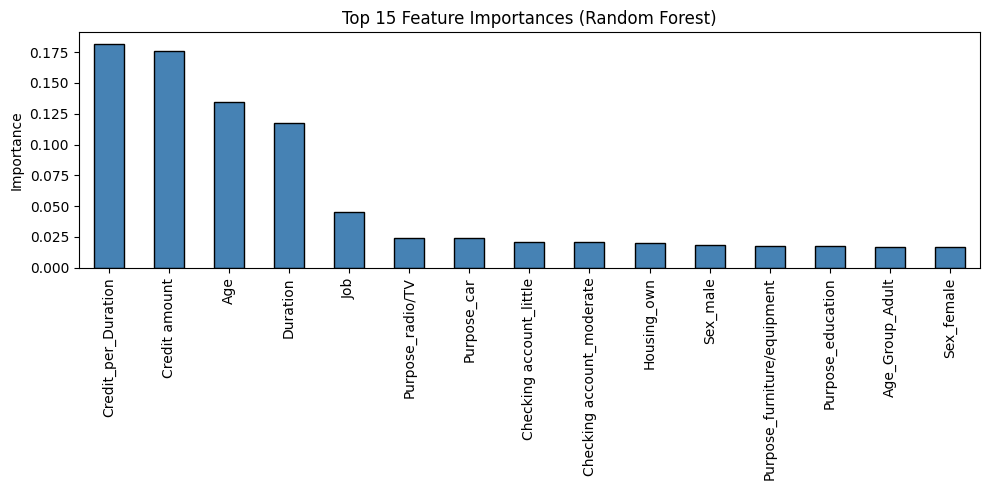

In [18]:
# Feature importance (Random Forest)
rf_pipe = eval_results['Random Forest']['pipeline']
ohe_cols = rf_pipe.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_features)
feature_names = num_features + list(ohe_cols)
importances = rf_pipe.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## 10. Model Selection & Deployment

In [19]:
# Select best model by ROC-AUC
best_name = max(eval_results, key=lambda k: eval_results[k]['auc'])
best_pipeline = eval_results[best_name]['pipeline']

print(f'Best Model : {best_name}')
print(f'Accuracy   : {eval_results[best_name]["acc"]:.4f}')
print(f'ROC-AUC    : {eval_results[best_name]["auc"]:.4f}')

Best Model : Random Forest
Accuracy   : 0.7300
ROC-AUC    : 0.6554


In [20]:
# Save best pipeline
joblib.dump(best_pipeline, '../model/credit_risk_model.pkl')
print('Model saved to ../model/credit_risk_model.pkl')

Model saved to ../model/credit_risk_model.pkl


In [21]:
# Verify: load and predict on a sample
loaded_model = joblib.load('../model/credit_risk_model.pkl')

sample = pd.DataFrame([{
    'Age': 35,
    'Sex': 'male',
    'Job': 2,
    'Housing': 'own',
    'Saving accounts': 'little',
    'Checking account': 'moderate',
    'Credit amount': 5000,
    'Duration': 24,
    'Purpose': 'car',
    'Credit_per_Duration': 5000 / 24,
    'Age_Group': 'Adult'
}])

pred  = loaded_model.predict(sample)[0]
proba = loaded_model.predict_proba(sample)[0][1]
label = 'HIGH RISK' if pred == 1 else 'LOW RISK'

print(f'Prediction       : {pred}')
print(f'Risk Probability : {proba:.4f}')
print(f'Risk Label       : {label}')

Prediction       : 0
Risk Probability : 0.2100
Risk Label       : LOW RISK
